In [1]:
import numpy as np
import random as rand
import matplotlib.pyplot as plt
import itertools
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import os
import json
import sys


In [2]:
# Get project root (2 levels up from current notebook location)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
 
# Define key directories
models_dir = os.path.join(project_root, 'Models')
trained_models_dir = os.path.join(project_root, 'Trained_Models')
simulated_data_dir = os.path.join(project_root, 'Simulated_Data')
results_dir = os.path.join(project_root, 'Results')
 
# Add Models to Python path
if models_dir not in sys.path:
    sys.path.insert(0, models_dir)
 
# Verify paths exist
print("=" * 60)
print("PROJECT PATHS VERIFICATION")
print("=" * 60)
print(f"Project Root:      {project_root}")
print(f"Models Dir:        {models_dir} ✓" if os.path.exists(models_dir) else f"Models Dir:        {models_dir} ✗")
print(f"Trained Models:    {trained_models_dir} ✓" if os.path.exists(trained_models_dir) else f"Trained Models:    {trained_models_dir} ✗")
print(f"Simulated Data:    {simulated_data_dir} ✓" if os.path.exists(simulated_data_dir) else f"Simulated Data:    {simulated_data_dir} ✗")
print(f"Results Dir:       {results_dir} ✓" if os.path.exists(results_dir) else f"Results Dir:       {results_dir} ✗")
print("=" * 60)

PROJECT PATHS VERIFICATION
Project Root:      /Users/GraceCeline/Bachelorarbeit
Models Dir:        /Users/GraceCeline/Bachelorarbeit/Models ✓
Trained Models:    /Users/GraceCeline/Bachelorarbeit/Trained_Models ✓
Simulated Data:    /Users/GraceCeline/Bachelorarbeit/Simulated_Data ✓
Results Dir:       /Users/GraceCeline/Bachelorarbeit/Results ✓


In [3]:
elo_dir = os.path.join(os.getcwd(), '..', 'Models')  # adjust folder name
sys.path.append(elo_dir)
from ELO import Elo
import joblib

In [4]:
def load_testing_data(scenario, split):
    base_path = "../Simulated_Data"
    
    filename = f"scenario_{scenario}_{split}_data.csv"
    filepath = os.path.join(base_path, filename)
    
    return pd.read_csv(filepath)

In [5]:
def load_bkt(scenario_id, base_dir=None):
    """
    Load a saved BKT model and its parameters for a given scenario.

    Args:
        scenario_id : scenario identifier (e.g. 1–6)
        base_dir    : optional override for the Trained_Models folder path

    Returns:
        model           : the loaded BKT model (via joblib)
        model_parameters: the loaded parameter dict (via JSON)
    """
    if base_dir is None:
        base_dir = os.path.join(project_root, 'Trained_Models')

    # Paths — must match exactly what was used in save_bkt
    model_path  = os.path.join(base_dir, f'BKT_model_scenario_{scenario_id}.pth')   # JSON params
    pkl_path    = os.path.join(base_dir, f'BKT_model_scenario_{scenario_id}.pkl')   # joblib model

    # Check both files exist before loading
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"No BKT params found for scenario {scenario_id} at:\n  {model_path}")
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(f"No BKT model found for scenario {scenario_id} at:\n  {pkl_path}")

    # Load the JSON parameters
    with open(model_path, 'r') as f:
        model_parameters = json.load(f)

    # Load the model object
    model = joblib.load(pkl_path)

    print(f"[Scenario {scenario_id}] BKT model loaded ← {pkl_path}")
    return model, model_parameters

In [6]:
def skill_display(optimal_skills):
    x_values = list(range(1, len(optimal_skills) + 1))
    # Convert data for plotting: organize skill levels into separate lists for each skill
    paired_lists = [
        [optimal_skills[j][i] for j in range(len(optimal_skills))]
        for i in range(len(optimal_skills[0]))
        ]
    num_lines = len(paired_lists) # Number of skills to plot
    colors = plt.cm.viridis(np.linspace(0, 1, num_lines)) # Generate a color palette
    plt.figure(figsize=(8, 4))
    plt.title("Optimization with ELO")
    # Plot each skill level over time
    for i in range(num_lines):
        plt.plot(paired_lists[i], linestyle='-', color=colors[i], label=f'Skill {i+1}')

    plt.xlabel('Time')
    plt.ylabel('Skill Level')
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
def skill_update_bkt(theta, q_matrix, d, model_parameters, task_id):
    """
    Updates skill levels using Bayesian Knowledge Tracing (BKT).

    Parameters:
        theta (np.array): Current skill levels.
        q (np.array): Skill-to-task mapping (Q-matrix).
        d (list): Dependencies for each skill.
        model_parameters (dict): BKT model parameters.
        task_id (int): ID of the current task.

    Returns:
        np.array: Updated skill levels.
    """
    # Ensure q is a NumPy array
    q = np.asarray(q_matrix)
    theta = np.copy(theta)  #  copy to avoid modifying the original array

    for i in range(len(theta)):
        if q[i] == 0:
            continue # Skip if the skill is not relevant to the task
        if d[i] >= 0 and theta[d[i]] < 1:
            continue # Ensure prerequisites are met

        p_trans = model_parameters[f"p_trans_{i}"]   # Learning transition probability
        theta[i] += p_trans * (1 - theta[i])   # Update skill level
    return theta

In [8]:
def skill_update_bkt_ELO(theta, q, d, model_parameters, task_id, correct):
    """
    Updates skill levels in BKT using ELO-based adjustments.

    Parameters:
        theta (np.array): Current skill levels.
        q (np.array): Skill-to-task mapping (Q-matrix).
        d (list): Dependencies for each skill.
        model_parameters (dict): BKT model parameters.
        task_id (int): ID of the current task.
        Success (int): 1 if the student succeeded, 0 otherwise.

    Returns:
        np.array: Updated skill levels.
    """
    theta = np.copy(theta)  # Avoid modifying the original array

    for i in range(len(theta)):
        if q[i] == 0:
            continue  # Skip if the skill is not relevant to the task
        if d[i] >= 0 and theta[d[i]] < 1:
            continue  # Ensure prerequisites are met

        p_trans   = model_parameters[f"p_trans_{i}"]
        p_guesses = pd.DataFrame(model_parameters[f"p_guesses_{i}"])
        p_slips   = pd.DataFrame(model_parameters[f"p_slips_{i}"])

        # Get guess and slip probabilities for the given task
        p_guess = p_guesses.loc[p_guesses['class'] == str(task_id), 'value'].values[0]
        p_slip  = p_slips.loc[p_slips['class'] == str(task_id), 'value'].values[0]

        # Update skill mastery based on success or failure
        if correct == 1:
            theta[i] = theta[i] * (1 - p_slip) / (theta[i] * (1 - p_slip) + (1 - theta[i]) * p_guess)
        else:
            theta[i] = theta[i] * p_slip / (theta[i] * p_slip + (1 - theta[i]) * (1 - p_guess))

        # Apply learning transition
        theta[i] += p_trans * (1 - theta[i])

    return theta

In [9]:
def correct_prediction(p, p_slip, p_guess):
    """
    Computes the probability of correctly predicting a skill.

    Args:
        p (float): Prior skill mastery probability.
        p_slip (float): Probability of slipping (incorrect response despite mastery).
        p_guess (float): Probability of guessing correctly without mastery.

    Returns:
        float: Probability of a correct response.
    """
    return (1 - p_slip) * p + (1 - p) * p_guess

In [10]:
import numpy as np
import pandas as pd

class BKTEloOptimization:
    def __init__(self, bkt_parameters, initial_skill_level, q_matrix, difficulty, depends, k_success, n, num_tasks, num_students=50):
        """
        Initialize BKT+ELO optimization framework
        
        Args:
            bkt_parameters: dict with 'p_L', 'p_S', 'p_G' (learn, slip, guess probabilities)
            initial_skill_level: initial K_t for each skill
            q_matrix: (num_skills, num_tasks) skill-task dependency matrix
            difficulty: task difficulty scores
            depends: skill dependencies
            k_success: ELO K-factor for successful predictions
            n: number of skill mastery levels
            num_tasks: total tasks available
            num_students: number of students to simulate
        """
        self.bkt_parameters = bkt_parameters
        self.initial_skill_level = initial_skill_level
        self.q_matrix = q_matrix
        self.difficulty = difficulty
        self.depends = depends
        self.k_success = k_success
        self.k_fail = 1.0 / n
        self.n = n
        self.num_tasks = num_tasks
        self.num_students = num_students
        self.p_op = self.calculate_p_op(n)
        
        self.mastery_threshold = 1.5
        self.max_steps = 30
    
    """
    def calculate_p_op(self):
        return (self.k_success + 1) / (self.k_success + self.k_fail + 2)
    """
    def calculate_p_op(self, n):
        return 0.5 - 1 / (2 * (n - 1))
    
    def get_p_guess(self, skill_id, task_id):
        """
        Extract guess probability for a specific skill-task pair.
        
        Args:
            skill_id (int): Skill identifier
            task_id (int): Task identifier
            
        Returns:
            float: Guess probability p_G for this skill-task pair
        """
        p_guesses_key = f"p_guesses_{skill_id}"
        p_guesses_list = self.bkt_parameters[p_guesses_key]
        
        # Search for matching task ID in the list
        for item in p_guesses_list:
            if item.get('class') == str(task_id):
                return item.get('value', 0.2)
        
        # If task not found, return first value or default
        return p_guesses_list[0]['value'] if p_guesses_list else 0.2

    def get_p_slip(self, skill_id, task_id):
        """
        Extract slip probability for a specific skill-task pair.
        
        Args:
            skill_id (int): Skill identifier
            task_id (int): Task identifier
            
        Returns:
            float: Slip probability p_S for this skill-task pair
        """
        p_slips_key = f"p_slips_{skill_id}"
        p_slips_list = self.bkt_parameters[p_slips_key]
        
        # Search for matching task ID in the list
        for item in p_slips_list:
            if item.get('class') == str(task_id):
                return item.get('value', 0.1)
        
        # If task not found, return first value or default
        return p_slips_list[0]['value'] if p_slips_list else 0.1

    def get_p_trans(self, skill_id):
        """Learning probability (same for all tasks)"""
        return self.bkt_parameters[f"p_trans_{skill_id}"]

    def get_p_start(self, skill_id):
        """Initial knowledge (same for all tasks)"""
        return self.bkt_parameters[f"p_start_{skill_id}"]
    
    def select_task_by_p_op_distance(self, student_id, bkt_knowledge_state):
        """
        Select task where P(correct) is closest to p_op (optimal practice point)
        
        Returns:
            selected_task_id: task index
            selected_task_probability: P(correct) for selected task
        """
        task_probabilities = np.zeros(self.num_tasks)
        
        for task_id in range(self.num_tasks):
            task_probabilities[task_id] = self.calculate_bkt_task_probability(
                student_id, task_id, bkt_knowledge_state
            )
        
        probability_differences_from_p_op = np.abs(task_probabilities - self.p_op)
        selected_task_id = np.argmin(probability_differences_from_p_op)
        
        return selected_task_id, task_probabilities[selected_task_id]
    
    def calculate_bkt_task_probability(self, student_id, task_id, bkt_knowledge_state):
        """Calculate P(correct) for a task using BKT"""
        skills_involved_in_task = np.where(self.q_matrix[:, task_id] > 0)[0]
        
        if len(skills_involved_in_task) == 0:
            return 0.5
        
        skill_probabilities = []
        
        for skill_id in skills_involved_in_task:
            p_trans = self.get_p_trans(skill_id)
            K_t = bkt_knowledge_state[skill_id]
            p_S = self.get_p_slip(skill_id, task_id)        # ← Add task_id
            p_G = self.get_p_guess(skill_id, task_id)       # ← Add task_id
            
            skill_probability_correct = K_t * (1 - p_S) + (1 - K_t) * p_G
            skill_probabilities.append(skill_probability_correct)
        
        return np.prod(skill_probabilities)
    
    def calculate_task_learning_potential(self, student_id, task_id, bkt_knowledge_state):
        """
        Calculate total learning potential for a task.
        
        Accounts for ALL skills involved in task - learning happens across all of them.
        Total learning = sum of learning gains for all involved skills
        
        Args:
            student_id (int): Student identifier
            task_id (int): Task identifier
            bkt_knowledge_state (np.array): Current K_t for each skill
            
        Returns:
            float: Total learning potential for this task
        """
        skills_involved = np.where(self.q_matrix[:, task_id] > 0)[0]
        
        if len(skills_involved) == 0:
            return 0.0
        
        # Calculate learning gain for each skill and sum them
        total_learning_gain = 0.0
        
        for skill_id in skills_involved:
            K_t = bkt_knowledge_state[skill_id]
            p_L = self.get_p_trans(skill_id)
            learning_gain = (1 - K_t) * p_L
            total_learning_gain += learning_gain
        
        return total_learning_gain
    
    
    def select_task_by_learning_gain(self, student_id, bkt_knowledge_state):
        """
        Select task that maximizes learning gain across all involved skills.
        
        NEW criterion: learning gain-based selection
        Accounts for:
          - Multiple skills learning simultaneously
          - Learning gain formula: (1 - K_t) * p_L for each skill
        
        Returns:
            int: Selected task ID that maximizes total learning potential
        """
        task_learning_gains = np.zeros(self.num_tasks)
        
        for task_id in range(self.num_tasks):
            task_learning_gains[task_id] = self.calculate_task_learning_potential(
                student_id, task_id, bkt_knowledge_state
            )
        
        # Select task with highest learning gain
        selected_task_id = np.argmax(task_learning_gains)
        
        return selected_task_id, task_learning_gains[selected_task_id]

    def update_bkt_knowledge(self, knowledge_state, skill_id, is_correct, task_id):
        """Update BKT knowledge state"""
        knowledge_state_updated = np.copy(knowledge_state)
        
        K_t = knowledge_state_updated[skill_id]
        p_L = self.get_p_trans(skill_id)
        p_S = self.get_p_slip(skill_id, task_id)            # ← Add task_id
        p_G = self.get_p_guess(skill_id, task_id)           # ← Add task_id
        
        if is_correct == 1:
            numerator = K_t * (1 - p_S)
            denominator = K_t * (1 - p_S) + (1 - K_t) * p_G
            K_posterior = numerator / denominator if denominator > 0 else K_t
        else:
            numerator = K_t * p_S
            denominator = K_t * p_S + (1 - K_t) * (1 - p_G)
            K_posterior = numerator / denominator if denominator > 0 else K_t
        
        K_t_updated = K_posterior + (1 - K_posterior) * p_L
        knowledge_state_updated[skill_id] = K_t_updated
        
        return knowledge_state_updated

    def optimize_learning_path(self):
        """
        Main optimization loop: find average steps to mastery across all students
        
        Returns:
            avg_steps_to_mastery: mean steps across all students
            final_skill_history: knowledge trajectory of last student
            p_op: optimal practice point used
        """
        mastery_results = []
        all_skill_histories = []
        
        num_skills = len(self.initial_skill_level)
        
        for student_id in range(self.num_students):
            # Step 1: Initialize skill levels for BKT and ELO
            bkt_knowledge_state = self.initial_skill_level.copy()
            elo_skill_levels = self.initial_skill_level.copy()
            
            step_number = 0
            reached_mastery_at_step = None
            knowledge_history = [bkt_knowledge_state.tolist()]
            
            # Step 3: While mastery not reached
            while np.any(elo_skill_levels < self.mastery_threshold) and step_number < self.max_steps:
                step_number += 1
                
                # Step 4: Select task with probability closest to p_op
                selected_task_id, learning_gain = self.select_task_by_learning_gain(
                    student_id, bkt_knowledge_state
                )
                
                # Debug output for first student
                # if student_id == 0:
                #     print(f"[Student 0] Step {step_number}: Selected Task {selected_task_id} with prob {learning_gain}")
                
                # Get skills needed for this task
                skills_needed = self.q_matrix[:, selected_task_id]
                
                # Simulate student response
                elo_skill_levels, task_response_correct = Elo.skill_update(
                    difficulty_level[selected_task_id],
                    elo_skill_levels,
                    skills_needed,
                    depends,
                    self.k_success,
                    self.k_fail
                )
                
                # Step 5: Update BKT knowledge for involved skills
                involved_skill_indices = np.where(skills_needed == 1)[0]
                for skill_id in involved_skill_indices:
                    bkt_knowledge_state = self.update_bkt_knowledge(
                        bkt_knowledge_state, skill_id, task_response_correct, selected_task_id
                    )
                
                knowledge_history.append(elo_skill_levels.tolist())
                
                # Debug output for first student
                if student_id == 0:
                   print(f"[Student 0]: Selected Task {selected_task_id} Knowledge state: {bkt_knowledge_state.tolist()}, Response: {task_response_correct}")
                
                # Step 7: Check if mastery reached (all skills >= threshold)
                if reached_mastery_at_step is None and np.all(elo_skill_levels >= self.mastery_threshold):
                    reached_mastery_at_step = step_number
            
            # Record results for this student
            mastery_results.append({
                "student_id": student_id + 1,
                "steps_to_mastery": reached_mastery_at_step,
                "p_op": self.p_op,
                "final_bkt_knowledge": bkt_knowledge_state.tolist(),
                "final_elo_skills": elo_skill_levels.tolist()
            })
            
            all_skill_histories.append(knowledge_history)
        
        # Compute statistics
        results_dataframe = pd.DataFrame(mastery_results)
        average_steps_to_mastery = results_dataframe["steps_to_mastery"].mean()
        std_steps_to_mastery = results_dataframe["steps_to_mastery"].std()
        final_skill_history_array = np.array(all_skill_histories[0])
        
        return average_steps_to_mastery, std_steps_to_mastery, final_skill_history_array, self.p_op

In [11]:
def run_optimization_bkt(bkt_parameters, num_tasks, num_skills, q_matrix, difficulty, depends, initial_skill_level, scenario_id, num_students=50):
    """
    Run BKT optimization with different p_op values and plot results.
    
    Args:
        bkt_parameters: dict with p_start_*, p_trans_*, p_guesses_*, p_slips_*
        num_tasks: number of tasks in scenario
        num_skills: number of skills
        q_matrix: skill-task dependency matrix
        difficulty: task difficulty scores
        depends: skill dependencies
        initial_skill_level: initial K_t for each skill
        scenario_id: scenario identifier for plotting
        num_students: number of students to simulate
    """
    results = []
    
    # Run with different n values (determines p_op: lower, normal, higher)
    # n=2 gives p_op = 0.5 - 1/(2*1) = 0.0
    # n=4 gives p_op = 0.5 - 1/(2*3) = 0.333
    # n=6 gives p_op = 0.5 - 1/(2*5) = 0.4
    
    print(f"Running BKT optimization for Scenario {scenario_id}...")
    
    # p_op ≈ 0.0 (harder tasks)
    optimizer_n2 = BKTEloOptimization(
        bkt_parameters=bkt_parameters,
        initial_skill_level=initial_skill_level.copy(),
        q_matrix=q_matrix,
        difficulty=difficulty,
        depends=depends,
        k_success=1,
        n=2,
        num_tasks=num_tasks,
        num_students=num_students
    )
    average_steps_p_op_0, std_steps_p_op_0, skill_history_n2, p_op_2 = optimizer_n2.optimize_learning_path()
    
    # p_op ≈ 0.333 (medium tasks)
    optimizer_n4 = BKTEloOptimization(
        bkt_parameters=bkt_parameters,
        initial_skill_level=initial_skill_level.copy(),
        q_matrix=q_matrix,
        difficulty=difficulty,
        depends=depends,
        k_success=1,
        n=4,
        num_tasks=num_tasks,
        num_students=num_students
    )
    average_steps_p_op_033, std_steps_p_op_033, skill_history_n4, p_op_4 = optimizer_n4.optimize_learning_path()
    
    # p_op ≈ 0.4 (easier,
    # {,lomjpoh89uzgiouz} tasks)
    optimizer_n6 = BKTEloOptimization(
        bkt_parameters=bkt_parameters,
        initial_skill_level=initial_skill_level.copy(),
        q_matrix=q_matrix,
        difficulty=difficulty,
        depends=depends,
        k_success=1,
        n=6,
        num_tasks=num_tasks,
        num_students=num_students
    )
    average_steps_p_op_04, std_steps_p_op_04, skill_history_n6, p_op_6 = optimizer_n6.optimize_learning_path()
    
    # Collect results
    results.append({
        "scenario": scenario_id,
        "p_op_0.0_mean": average_steps_p_op_0,
        "p_op_0.0_std": std_steps_p_op_0,
        "p_op_0.33_mean": average_steps_p_op_033,
        "p_op_0.33_std": std_steps_p_op_033,
        "p_op_0.4_mean": average_steps_p_op_04,
        "p_op_0.4_std": std_steps_p_op_04,
    })
    
    results_table = pd.DataFrame(results)
    print("\nBKT Optimization Results:")
    print(results_table)
    results_table.to_csv(f'../../Results/bkt_results_scenario_{scenario_id}.csv', index=False)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    data = [
        (skill_history_n2, f'p_op = {p_op_2:.4f} (n=2)', 'o'),
        (skill_history_n4, f'p_op = {p_op_4:.4f} (n=4)', 's'),
        (skill_history_n6, f'p_op = {p_op_6:.4f} (n=6)', '^')
    ]
    colors = [('blue', 'blue'), ('orange', 'green'), ('purple', 'brown')]
    
    for ax, (skill_hist, title, marker), (c1, c2) in zip(axes, data, colors):
        steps = range(skill_hist.shape[0])
        
        ax.plot(steps, skill_hist[:, 0], marker=marker, label='Skill 0', 
                linewidth=2, color=c1, markersize=6)
        ax.plot(steps, skill_hist[:, 1], marker=marker, label='Skill 1', 
                linewidth=2, color=c2, markersize=6)
        
        ax.axhline(y=1.5, color='red', linestyle='--', linewidth=1.5, 
                   label='Mastery Threshold (1.5)')
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Step', fontsize=11)
        ax.set_ylabel('ELO Skill Level', fontsize=11)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 2.0])
    
    fig.suptitle(f'BKT+ELO Skill Mastery Progression — Scenario {scenario_id}', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return results_table, {
        'p_op_0': (average_steps_p_op_0, skill_history_n2),
        'p_op_333': (average_steps_p_op_033, skill_history_n4),
        'p_op_4': (average_steps_p_op_04, skill_history_n6)
    }

# Optimization BKT

In [12]:
with open('../../elo_variable.json', 'r') as Elo_Data:
    elo_data = json.load(Elo_Data)

print(elo_data)

{'globals': {'students': 500, 'init_skill_level': [0.0, 0.0], 'k_success': 1, 'k_fail': 0.5}, 'scenarios': [{'id': 1, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 0], [0, 1]], 'difficulty_level': [1, 1], 'depends': [-1, -1]}, {'id': 2, 'num_tasks': 2, 'num_skills': 2, 'q_matrix': [[1, 1], [1, 1]], 'difficulty_level': [0, 1], 'depends': [-1, -1]}, {'id': 3, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0], [0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1], 'depends': [-1, -1, -1, -1]}, {'id': 4, 'num_tasks': 4, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1], [0, 1, 1, 1]], 'difficulty_level': [1, 1, 0, 1], 'depends': [-1, -1, -1, -1]}, {'id': 5, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1]], 'difficulty_level': [0, 0, 0, 1, 1, 1], 'depends': [-1, -1, -1, -1, -1, -1]}, {'id': 6, 'num_tasks': 6, 'num_skills': 2, 'q_matrix': [[1, 0, 1, 0, 1, 0], [0, 1, 0, 1, 0, 1]], 'difficulty_level': [0, 0, 1, 1, 2, 2], 'depends': [-1, -1, -1, -1, -1, -1]}

In [13]:
all_data = {}

level_skill   = [] 
i = 0

global_values = elo_data["globals"]
scenarios = elo_data["scenarios"]

students          = global_values["students"]
# init_skill_level  = np.array(global_values["init_skill_level"])
k_success         = global_values["k_success"]
# k_fail            = global_values["k_fail"]

In [14]:
bkt, bkt_params = load_bkt(5)
print("DEBUG SCENARIO 5 ", bkt_params)

[Scenario 5] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_5.pkl
DEBUG SCENARIO 5  {'p_start_0': 0.003774777602005301, 'p_trans_0': 0.4043128208280229, 'p_guesses_0': [{'class': '0', 'value': 0.49616542381678236}, {'class': '2', 'value': 0.2336140631866575}, {'class': '3', 'value': 0.24012898818426012}, {'class': '5', 'value': 0.07047648401200961}], 'p_slips_0': [{'class': '0', 'value': 0.14504318010759612}, {'class': '2', 'value': 0.31755707838398267}, {'class': '3', 'value': 0.3294214367255529}, {'class': '5', 'value': 0.6621174281503062}], 'p_start_1': 0.0006593541771949474, 'p_trans_1': 0.36815928370388307, 'p_guesses_1': [{'class': '1', 'value': 0.515116019153531}, {'class': '2', 'value': 0.22872702617800877}, {'class': '4', 'value': 0.3011613614378415}, {'class': '5', 'value': 0.03172816717298751}], 'p_slips_1': [{'class': '1', 'value': 0.1740270491614979}, {'class': '2', 'value': 0.2976360426844134}, {'class': '4', 'value': 0.329101553167

[Scenario 1] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_1.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.004205633837411831, 'p_trans_0': 0.3012705235697029, 'p_guesses_0': [{'class': '0', 'value': 0.2739527135186627}], 'p_slips_0': [{'class': '0', 'value': 0.272045841776864}], 'p_start_1': 0.03917168282727392, 'p_trans_1': 0.25404059032913556, 'p_guesses_1': [{'class': '1', 'value': 0.25418657968077163}], 'p_slips_1': [{'class': '1', 'value': 0.23159807947418248}]}
-------------- RESULTS FOR SCENARIO 1------------------
Running BKT optimization for Scenario 1...
[Student 0]: Selected Task 0 Knowledge state: [0.3012705235697029, 0.0], Response: 1
[Student 0]: Selected Task 1 Knowledge state: [0.3012705235697029, 0.25404059032913556], Response: 1
[Student 0]: Selected Task 0 Knowledge state: [0.3984542265092892, 0.25404059032913556], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.3984542265092892, 0.32538332437301043], Respons

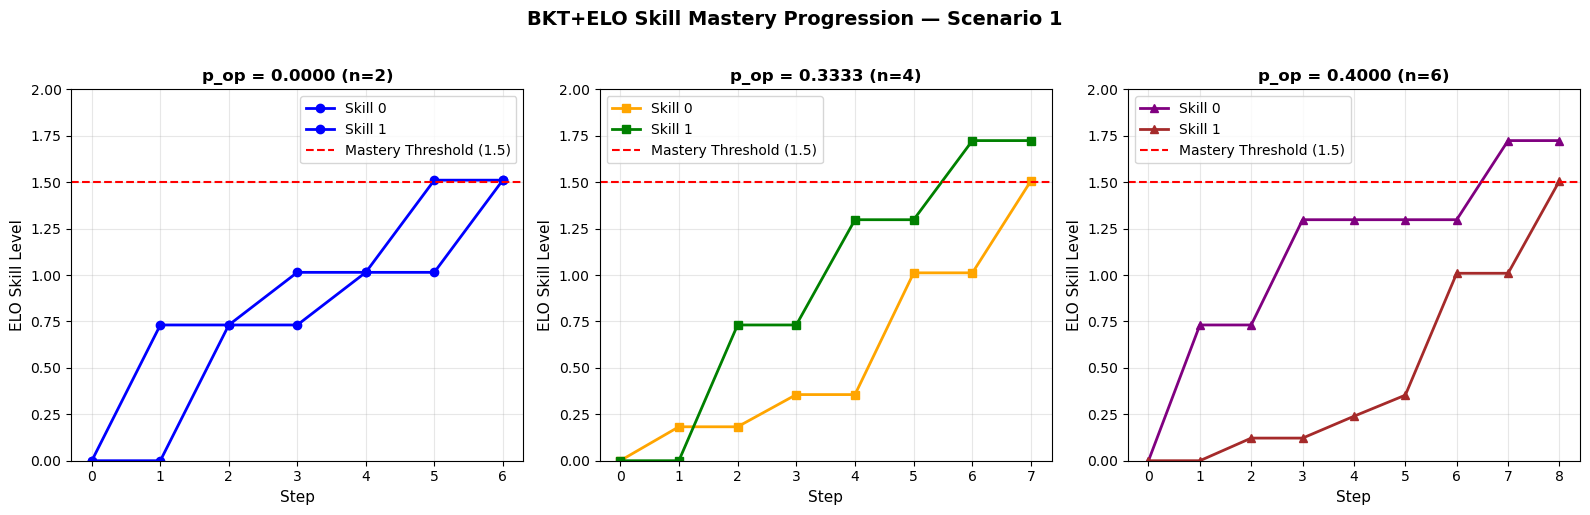

[Scenario 2] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_2.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.03142076541382259, 'p_trans_0': 0.36772473510976317, 'p_guesses_0': [{'class': '0', 'value': 0.22575884847485295}, {'class': '1', 'value': 0.05908270304019369}], 'p_slips_0': [{'class': '0', 'value': 0.33295547779359647}, {'class': '1', 'value': 0.6768830861167073}], 'p_start_1': 0.013483801803146369, 'p_trans_1': 0.3558811989547763, 'p_guesses_1': [{'class': '0', 'value': 0.23523825377967597}, {'class': '1', 'value': 0.06499711309928267}], 'p_slips_1': [{'class': '0', 'value': 0.3258120967142842}, {'class': '1', 'value': 0.6722393668456792}]}
-------------- RESULTS FOR SCENARIO 2------------------
Running BKT optimization for Scenario 2...
[Student 0]: Selected Task 0 Knowledge state: [0.36772473510976317, 0.3558811989547763], Response: 0
[Student 0]: Selected Task 0 Knowledge state: [0.7674098624243827, 0.7506776675357173], Response: 

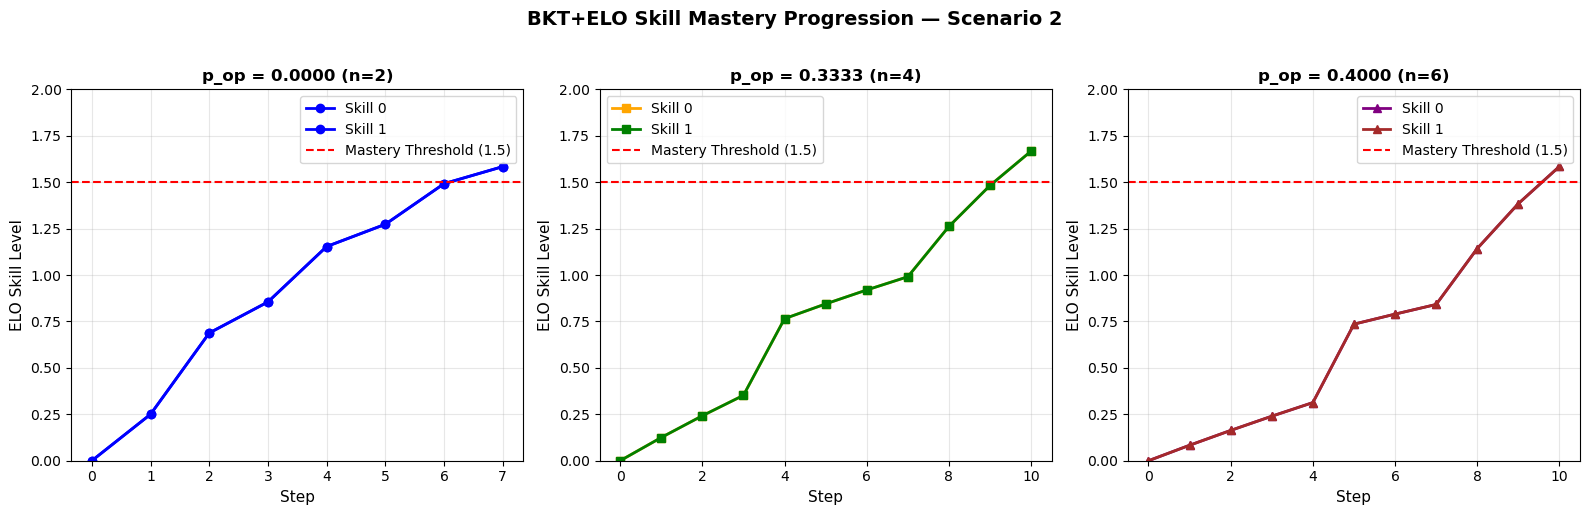

[Scenario 3] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_3.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.09355886963745717, 'p_trans_0': 0.34125514806225005, 'p_guesses_0': [{'class': '0', 'value': 0.44235824859952383}, {'class': '2', 'value': 0.2222345144150558}], 'p_slips_0': [{'class': '0', 'value': 0.12408039178028646}, {'class': '2', 'value': 0.3277130999542538}], 'p_start_1': 0.07098949893450807, 'p_trans_1': 0.26870596327552393, 'p_guesses_1': [{'class': '1', 'value': 0.5155577301697168}, {'class': '3', 'value': 0.2429917845792239}], 'p_slips_1': [{'class': '1', 'value': 0.08096733298916535}, {'class': '3', 'value': 0.2567632403018217}]}
-------------- RESULTS FOR SCENARIO 3------------------
Running BKT optimization for Scenario 3...
[Student 0]: Selected Task 0 Knowledge state: [0.34125514806225005, 0.0], Response: 0
[Student 0]: Selected Task 1 Knowledge state: [0.34125514806225005, 0.26870596327552393], Response: 0
[Student 0]: 

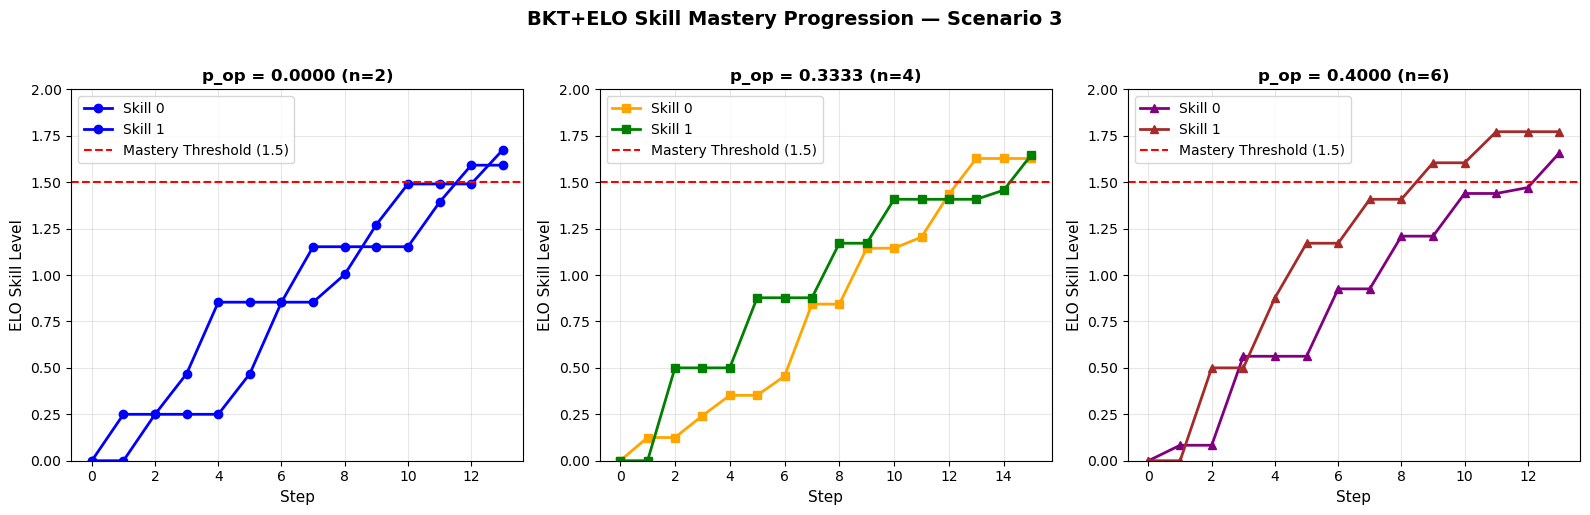

[Scenario 4] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_4.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.029908037581957023, 'p_trans_0': 0.36187708015281045, 'p_guesses_0': [{'class': '0', 'value': 0.27815817271821935}, {'class': '2', 'value': 0.21788830896751493}, {'class': '3', 'value': 0.04990636188375124}], 'p_slips_0': [{'class': '0', 'value': 0.33296043794700797}, {'class': '2', 'value': 0.33072036316637293}, {'class': '3', 'value': 0.6640867124274484}], 'p_start_1': 0.0023723495086068057, 'p_trans_1': 0.36120227703743696, 'p_guesses_1': [{'class': '1', 'value': 0.26179752388309674}, {'class': '2', 'value': 0.22332053578493719}, {'class': '3', 'value': 0.07037776957806854}], 'p_slips_1': [{'class': '1', 'value': 0.3639766107097341}, {'class': '2', 'value': 0.33867237674644884}, {'class': '3', 'value': 0.6695704892672013}]}
-------------- RESULTS FOR SCENARIO 4------------------
Running BKT optimization for Scenario 4...
[Student 0]:

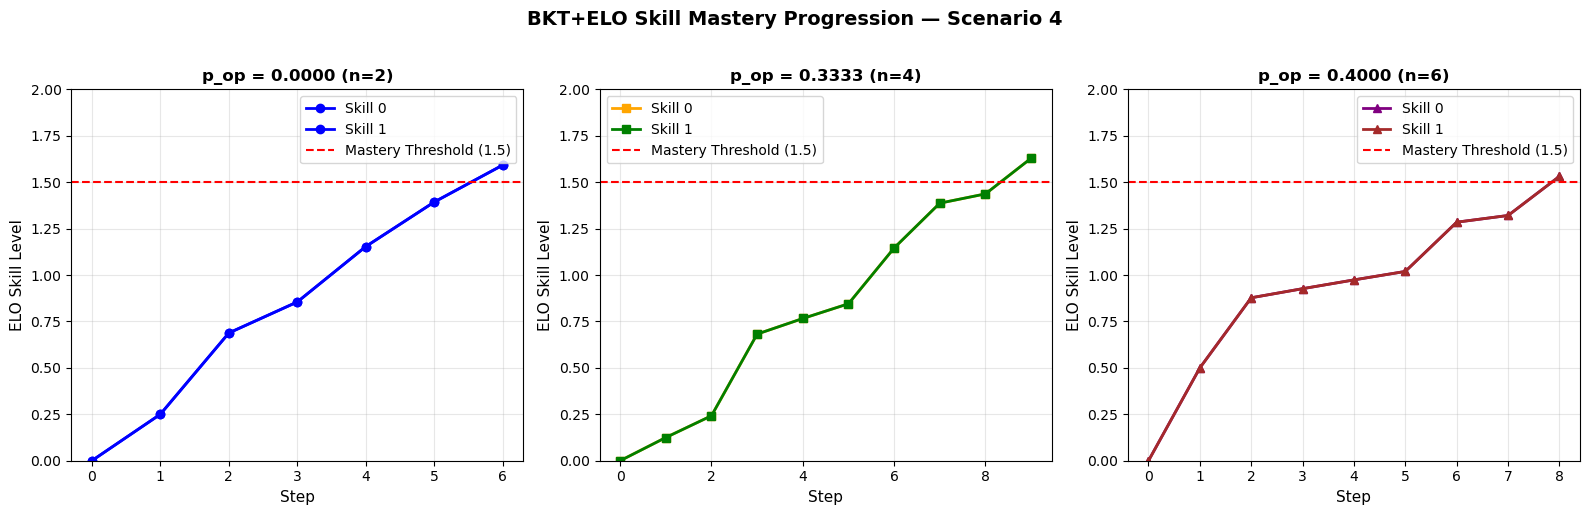

[Scenario 5] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_5.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.003774777602005301, 'p_trans_0': 0.4043128208280229, 'p_guesses_0': [{'class': '0', 'value': 0.49616542381678236}, {'class': '2', 'value': 0.2336140631866575}, {'class': '3', 'value': 0.24012898818426012}, {'class': '5', 'value': 0.07047648401200961}], 'p_slips_0': [{'class': '0', 'value': 0.14504318010759612}, {'class': '2', 'value': 0.31755707838398267}, {'class': '3', 'value': 0.3294214367255529}, {'class': '5', 'value': 0.6621174281503062}], 'p_start_1': 0.0006593541771949474, 'p_trans_1': 0.36815928370388307, 'p_guesses_1': [{'class': '1', 'value': 0.515116019153531}, {'class': '2', 'value': 0.22872702617800877}, {'class': '4', 'value': 0.3011613614378415}, {'class': '5', 'value': 0.03172816717298751}], 'p_slips_1': [{'class': '1', 'value': 0.1740270491614979}, {'class': '2', 'value': 0.2976360426844134}, {'class': '4', 'value': 0.

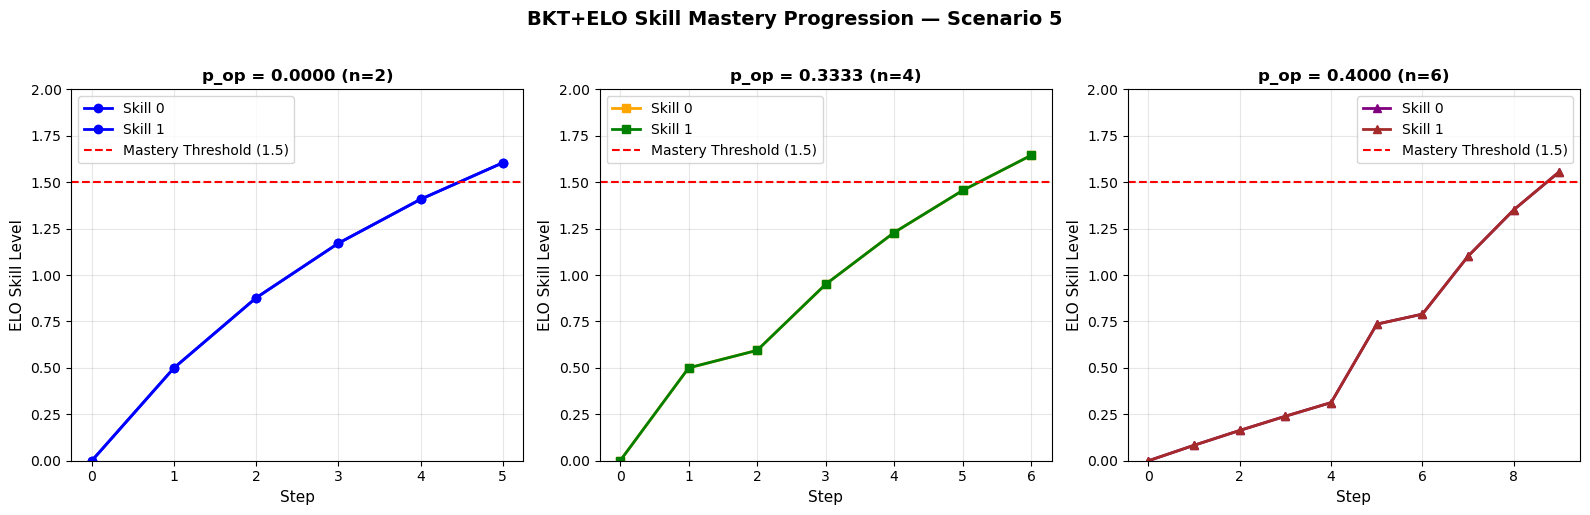

[Scenario 6] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_6.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.014914742754298094, 'p_trans_0': 0.27024732609775554, 'p_guesses_0': [{'class': '0', 'value': 0.5373212709460954}, {'class': '2', 'value': 0.2820419234050448}, {'class': '4', 'value': 0.10257618467520607}], 'p_slips_0': [{'class': '0', 'value': 0.08133675145417474}, {'class': '2', 'value': 0.22446542362181085}, {'class': '4', 'value': 0.5054027287136295}], 'p_start_1': 0.03433221001363195, 'p_trans_1': 0.24708828766675286, 'p_guesses_1': [{'class': '1', 'value': 0.5448279495910718}, {'class': '3', 'value': 0.24635541120290894}, {'class': '5', 'value': 0.0570808608404038}], 'p_slips_1': [{'class': '1', 'value': 0.09310442301526453}, {'class': '3', 'value': 0.26071464888532314}, {'class': '5', 'value': 0.48338101082400703}]}
-------------- RESULTS FOR SCENARIO 6------------------
Running BKT optimization for Scenario 6...
[Student 0]: Sel

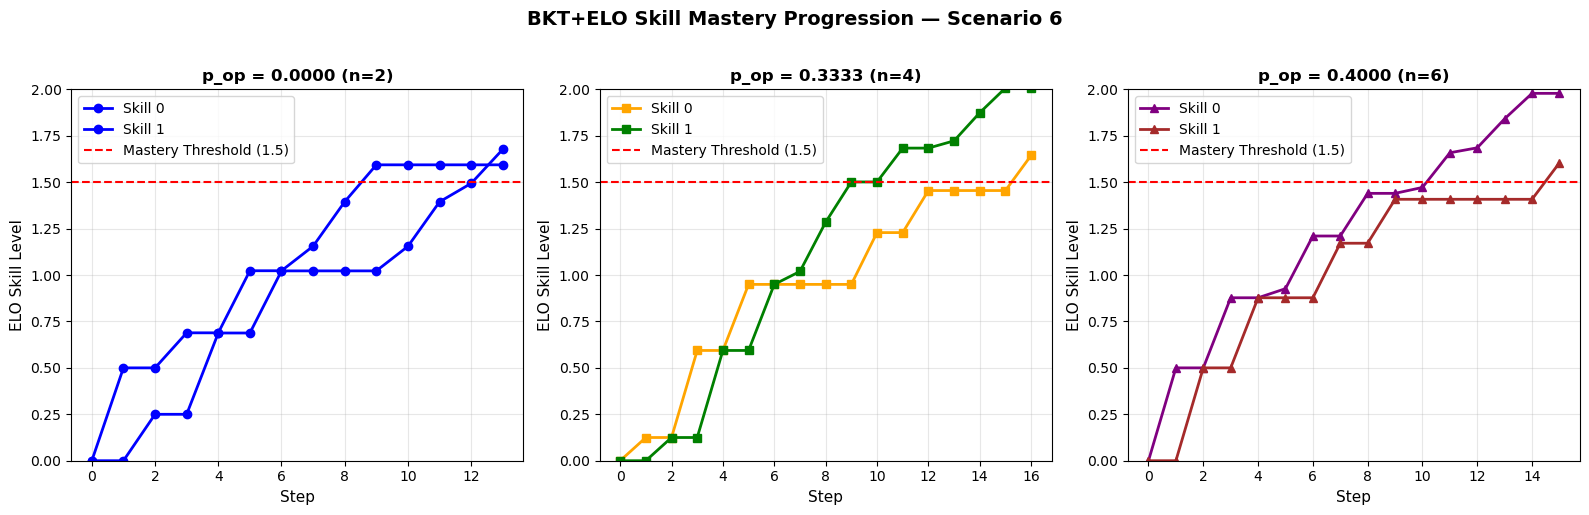

[Scenario 7] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_7.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.010013977005050662, 'p_trans_0': 0.29581082125068103, 'p_guesses_0': [{'class': '0', 'value': 0.08693608498844035}, {'class': '1', 'value': 0.5197475664482796}, {'class': '4', 'value': 0.07233175240479535}, {'class': '5', 'value': 0.10984574897754999}, {'class': '7', 'value': 9.379257536055692e-15}], 'p_slips_0': [{'class': '0', 'value': 0.538391804557366}, {'class': '1', 'value': 0.09955932570943872}, {'class': '4', 'value': 0.6079965300821196}, {'class': '5', 'value': 0.539136467243691}, {'class': '7', 'value': 0.9274995033795516}], 'p_start_1': 0.006323995952012601, 'p_trans_1': 0.2854863934362043, 'p_guesses_1': [{'class': '0', 'value': 0.05953118207496894}, {'class': '2', 'value': 0.10278461058574492}, {'class': '5', 'value': 0.11198721572241771}, {'class': '6', 'value': 0.5180786892246877}, {'class': '7', 'value': 3.30789083768639

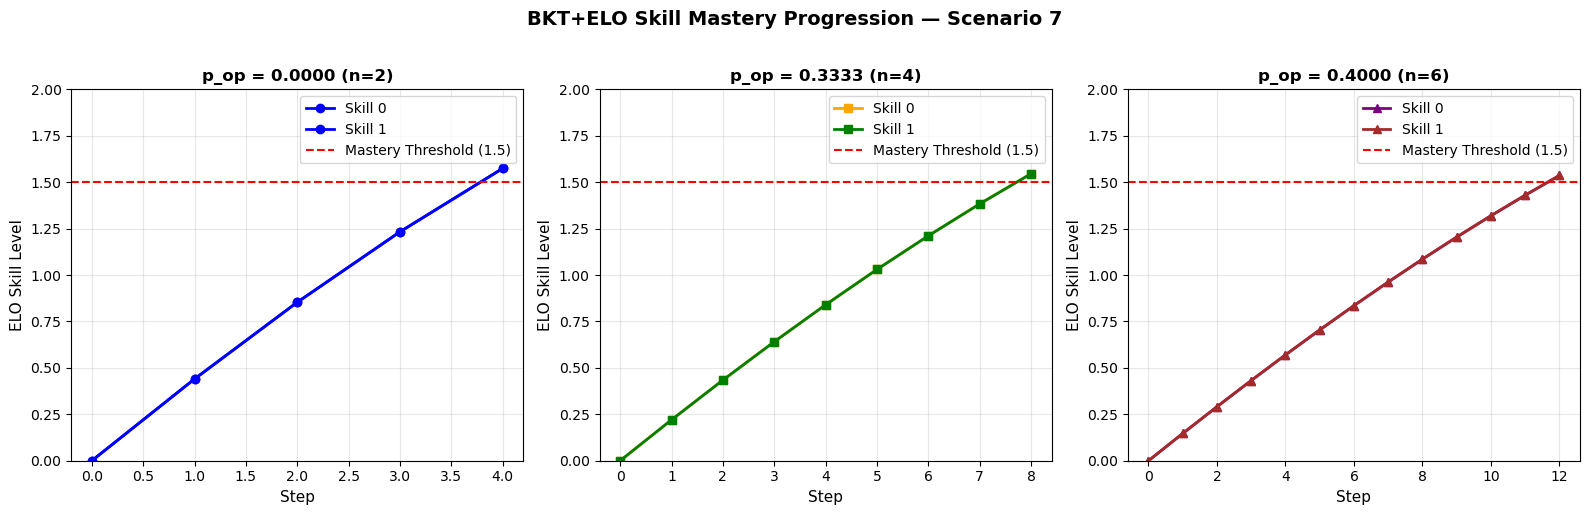

[Scenario 8] BKT model loaded ← /Users/GraceCeline/Bachelorarbeit/Trained_Models/BKT_model_scenario_8.pkl
DEBUG SCENARIO {scenario_id}  {'p_start_0': 0.041812130052854606, 'p_trans_0': 0.2776858627145359, 'p_guesses_0': [{'class': '0', 'value': 0.5465819252713988}, {'class': '2', 'value': 0.2236088975683445}, {'class': '4', 'value': 0.07968664982935603}, {'class': '6', 'value': 0.012883927684389989}], 'p_slips_0': [{'class': '0', 'value': 0.08516940140144347}, {'class': '2', 'value': 0.2126228148875468}, {'class': '4', 'value': 0.47522233233806394}, {'class': '6', 'value': 0.7312770690989965}], 'p_start_1': 0.019876193772694575, 'p_trans_1': 0.22437726282221584, 'p_guesses_1': [{'class': '1', 'value': 0.5364978145401709}, {'class': '3', 'value': 0.3174569579555497}, {'class': '5', 'value': 0.10995397071169791}, {'class': '7', 'value': 0.018577140317445073}], 'p_slips_1': [{'class': '1', 'value': 0.013672419157171262}, {'class': '3', 'value': 0.18347857618279492}, {'class': '5', 'value'

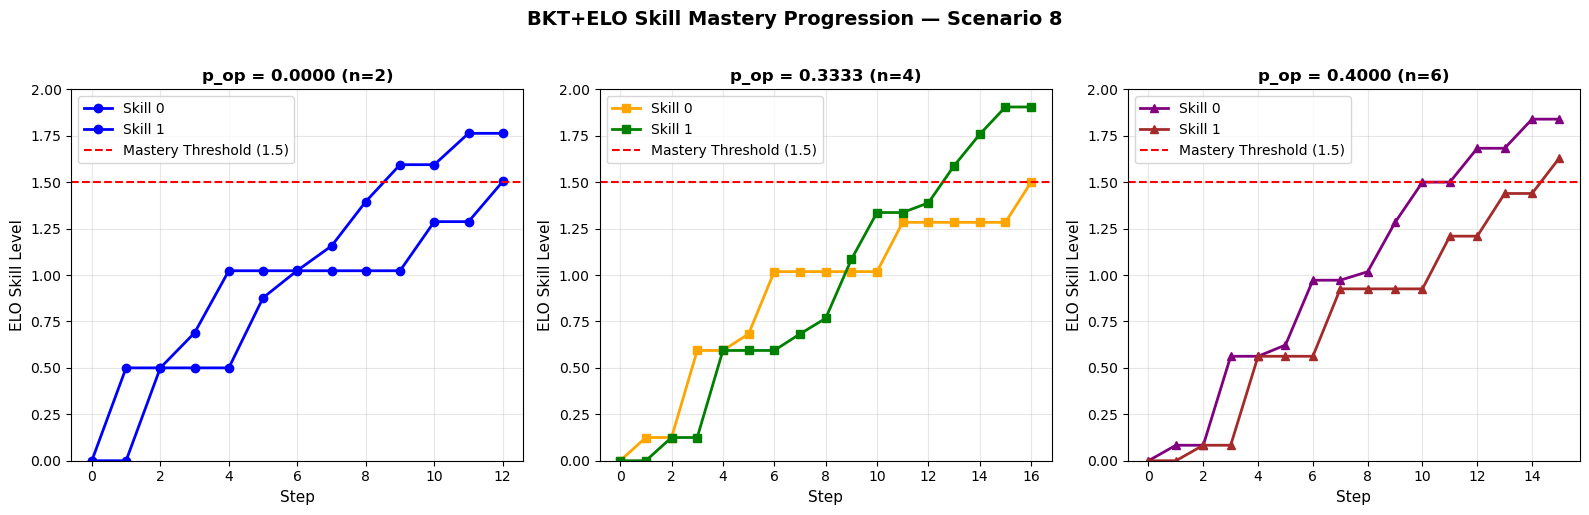

In [15]:
import sys

for scenario in scenarios:
        scenario_id    = scenario["id"]
        num_tasks      = scenario["num_tasks"]
        num_skills     = scenario["num_skills"]
        init_skill_level  = np.array([0.0] * num_skills)
        difficulty_level = np.array(scenario["difficulty_level"])
        q_matrix       = np.array(scenario["q_matrix"])
        depends = np.array(scenario["depends"])
        
        bkt, bkt_params = load_bkt(scenario_id)
        print("DEBUG SCENARIO {scenario_id} ", bkt_params)
        
        print(f"-------------- RESULTS FOR SCENARIO {scenario_id}------------------")

        results_bkt, histories_bkt = run_optimization_bkt(
            bkt_parameters=bkt_params,
            num_tasks=q_matrix.shape[1],
            num_skills=q_matrix.shape[0],
            q_matrix=q_matrix,
            difficulty=difficulty_level,
            depends=depends,
            initial_skill_level=init_skill_level,
            scenario_id=scenario_id,
            num_students=500
        )
        
        
        """avg_steps, skill_history, p_op = optimizer.optimize_learning_path()
        
        print(f"\nResults:")
        print(f"Average steps to mastery: {avg_steps:.2f}")
        print(f"Optimal practice point (p_op): {p_op:.4f}")
        print(f"Final skill history shape: {skill_history.shape}")
        """

BKT Observations:
- Adding multiple skill probs will automatically lead to blocking ( perfecting one skill first and then the other)